# A-SCLC

Edit the input path and device parameters, load the measurements, and inspect
the measured current density.
CSV format: `U(V),I(A)` with two numeric columns in that order (volts,
amperes). Raw measurements retain their signs and order.

In [1]:
from pathlib import Path
import sys

import numpy as np

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from asclc_workflow import (run_calculation, run_effective_mobility,
                            run_carrier_densities, run_model_occupations,
                            run_model_fermi_level, run_measured_fermi_level, run_model_current, run_model_mobility, run_density_derivatives, export_results)
from asclc_backend import equal_density_voltage, trap_dos, K_B, E_CHARGE, total_dos
from asclc_plotting import (plot_measured_jv, plot_smoothed_jv,
                            plot_local_gamma, plot_effective_mobility,
                            plot_carrier_densities, plot_carrier_fraction,
                            plot_dos, plot_fermi_dirac, plot_model_occupations, plot_model_fermi_level,
                            plot_model_current, plot_model_transport_energy, plot_hole_current_semilog, plot_trapped_charge, plot_fermi_energy, plot_density_energy)

## Input and sample parameters

Sample: MAPbBr3, S2, dark. Replace for your sample.


In [2]:
input_path = project_root / "data/MAPbBr3_S2_dark.csv"


experiment = dict(
    date="27.09.2024",
    sample="S2",
    regime="dark",
    voltage=(3, -3),   # V
    T=299.00,          # K
    T0=273.15,         # K
)


material = dict(
    L=6.00e-4,      # m, thickness
    S=7.70e-6,      # m^2, area
    eps_r=25.50,    # relative permittivity
    E_c=-3.36,      # eV, conduction band edge
    E_v=-5.58,      # eV, valence band edge
    E_g=2.22,       # eV, band gap
    m_eff_p=0.305,  # hole effective mass / m_e
    m_eff_e=0.320,  # electron effective mass / m_e
)

# Model: hand-selected parameters, Table S2 "Variable"
# (examples/MAPbBr3_S2.params). mu_0 is the reference line on the
# effective-mobility plot and the microscopic mobility of equation (5).
params = dict(
    mu_0=2.7e-3,    # m^2 V^-1 s^-1, microscopic mobility
    N_t=4.7e16,
    E_t=-4.82,
    T_t=30.0,
    E_F0=-4.84,
)




# docs/ASCLC_guide.md, "Local-slope smoothing window".
numerics = dict(window=11)


## Axis limits

Every chart cell below ends with `apply_limits`, carrying that chart's four
axis ends: `x=(left, right)` and `y=(bottom, top)`. Each end is either `"auto"`,
which follows the data, or a number, which fixes it. The ends written in the
cells reproduce the limits the figures were drawn with.


In [3]:
def apply_limits(axes, x=("auto", "auto"), y=("auto", "auto")):
    """Set the ends of one axes or a pair; an end written "auto" follows the data.

    x is (left, right) and y is (bottom, top). The horizontal ends go to the
    first axes only, so a paired axis with its own horizontal scale keeps it;
    the vertical ends go to every axes in the pair.
    """
    def manual(**ends):
        return {key: end for key, end in ends.items() if end != "auto"}

    axes = list(axes) if isinstance(axes, tuple) else [axes]
    axes[0].set_xlim(**manual(left=x[0], right=x[1]))
    for axis in axes:
        axis.set_ylim(**manual(bottom=y[0], top=y[1]))


In [4]:
device = dict(area=material["S"], voltage_offset=0.0)
result = run_calculation(input_path, device=device)
print(f"Loaded {result.V.size} measurements; "
      f"{(~result.measurements.finite).sum()} nonfinite rows retained.")

Loaded 214 measurements; 0 nonfinite rows retained.


## Measured current density

Measured current density against voltage on logarithmic axes. Nonpositive
readings are kept in the data but cannot appear on a logarithmic axis.

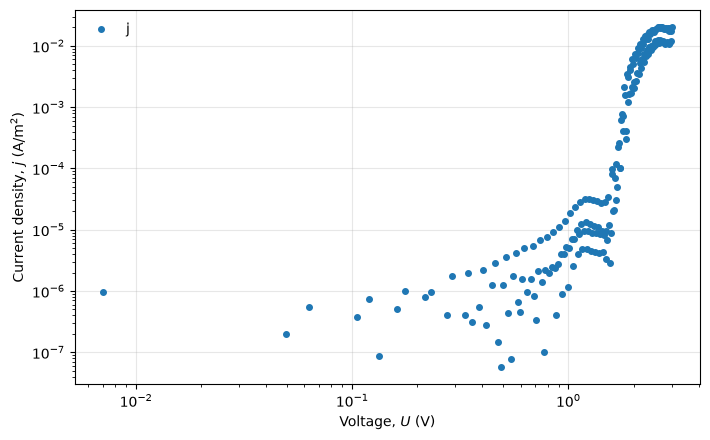

In [5]:
figures = {}
fig, ax = plot_measured_jv(result)
apply_limits(ax, x=("auto", "auto"), y=("auto", "auto"))
figures["measured_jv"] = fig

## Smoothed current density

A centred `numerics["window"]`-point mean of the current density, drawn over the
raw markers at the same voltages so the two can be compared directly. Points
near either end, where the window would run off the data, have no smoothed
value.

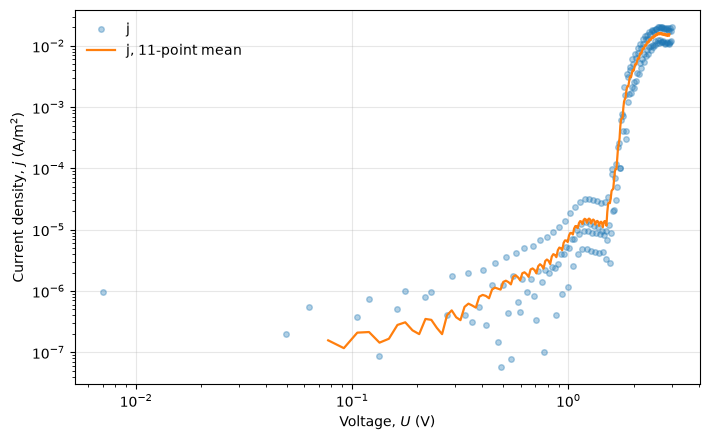

In [6]:
fig_s, ax_s = plot_smoothed_jv(result, window=numerics["window"])
apply_limits(ax_s, x=("auto", "auto"), y=("auto", "auto"))
figures["smoothed_jv"] = fig_s

## Slope parameter and effective mobility

Guide steps A2 and A3. Each row covers the same trailing
`numerics["window"]`-point window starting at that row:

- `U` and `j`: trailing means of voltage and current density.
- `gamma`: Least-squares fit of `ln|U|` against `ln|j|` over the window,
  fitted on the raw rows.
- `mu_eff`: equation (4) of the paper on that row's `U`, `j` and `gamma`,

$$\mu_\mathrm{eff} = \mu_0\Theta =
  \frac{L^3}{\varepsilon_0\varepsilon_r(1-\gamma)(2-\gamma)^2}\,\frac{j}{U^2}.$$

The anchor is trailing, so a row describes the window just above it and the last
`window - 1` rows have no value. Plot against `mobility.U`, the voltage each row
describes.

gamma, first six rows: [-0.1449  0.1648 -0.0097 -0.0201 -0.0279  0.0532]


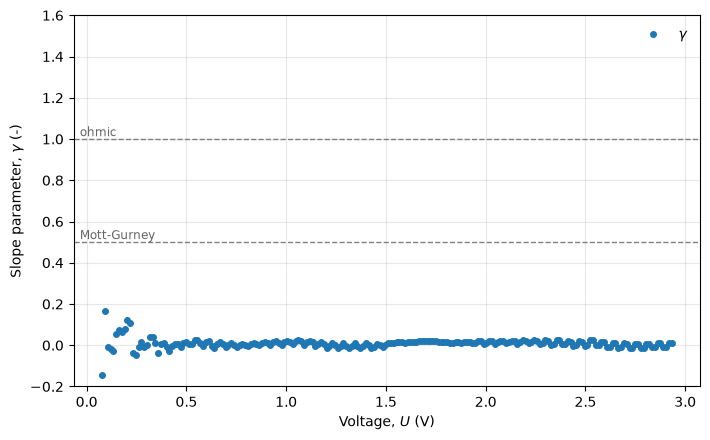

In [7]:
mobility = run_effective_mobility(result, material=material,
                                  window=numerics["window"])
fig_g, ax_g = plot_local_gamma(result, mobility)
apply_limits(ax_g, x=("auto", "auto"), y=("auto", "auto"))
figures["local_gamma"] = fig_g
print(f"gamma, first six rows: "
      f"{np.array2string(mobility.gamma[:6], precision=4)}")

Equation (4) diverges at `gamma = 1` (ohmic) and returns a negative mobility
where `gamma > 1`; such points stay in the data but cannot appear on a
logarithmic axis. The first decade of bias is at the instrument's noise floor,
where `gamma` is fitted through sign-flipping picoamps — read the physics above
about 0.3 V.

mu_eff defined at 204 of 214 points; maximum 5.998e-04 m^2 V^-1 s^-1 (0.22 x mu_0)


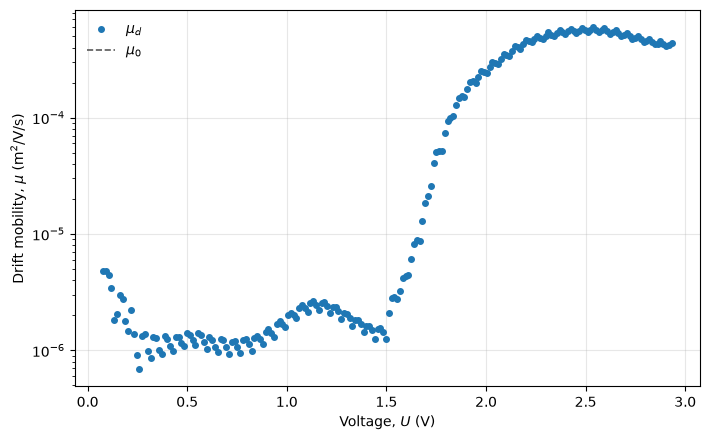

In [8]:
fig_m, ax_m = plot_effective_mobility(result, mobility, mu_0=params["mu_0"])
apply_limits(ax_m, x=("auto", "auto"), y=("auto", "auto"))
figures["effective_mobility"] = fig_m
finite = np.isfinite(mobility.mu_eff)
print(f"mu_eff defined at {finite.sum()} of {finite.size} points; "
      f"maximum {np.nanmax(mobility.mu_eff):.3e} m^2 V^-1 s^-1 "
      f"({np.nanmax(mobility.mu_eff) / params['mu_0']:.2f} x mu_0)")

## Free and trapped charge carriers

Guide step A4, on the same rows as step A3. Equation (5) is Ohm's law for these
devices solved for the free concentration, and equation (6) is what is left when
equation (2) is divided by it:

$$p_\mathrm{f} = \frac{L\,j}{e\mu_0(2-\gamma)U},\qquad
  \frac{p_\mathrm{f}}{\Theta} =
  \frac{\varepsilon_0\varepsilon_r(1-\gamma)(2-\gamma)U}{eL^2}.$$

The article labels the second quantity $p_\mathrm{t}$ and then sets
$\Theta = p_\mathrm{f}/(p_\mathrm{f}+p_\mathrm{t})$, which cannot hold together
with equations (2) and (4). Read as the *total* concentration $p_\mathrm{s}$,
with $p_\mathrm{t} = p_\mathrm{s} - p_\mathrm{f}$, the equations become one
system with a single $\Theta = \mu_\mathrm{eff}/\mu_0$ — equal to 1 in the
Mott–Gurney limit and to 1/2 where $p_\mathrm{t} = p_\mathrm{f}$, as the article
states for both regions. That is `theta_model="free_over_total"`, the default;
`"absolute_over_total"` (the SI read literally) and `"mobility_ratio"` (the mobility ratio) are the alternatives. Only `mu_0` separates the three
$p_\mathrm{f}$ curves from each other — it scales $p_\mathrm{f}$ and leaves
equation (6) untouched.

at U = 2.93 V:  p_f = 3.667e+15,  p_t = 1.885e+16,  p_s = 2.252e+16 m^-3
largest p_t: 1.952e+16 m^-3 (1.952e+10 cm^-3)


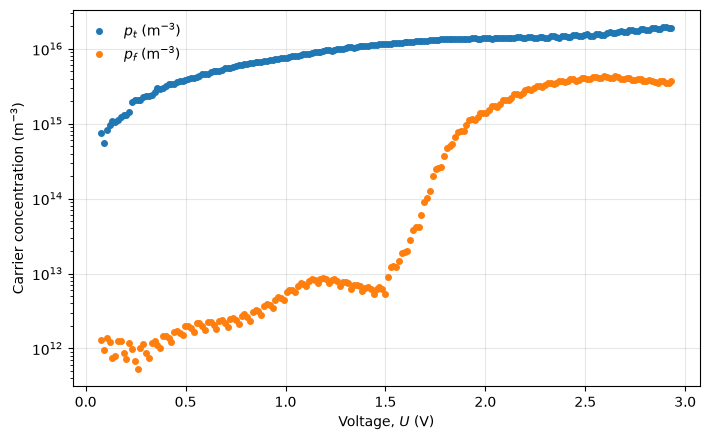

In [9]:
carriers = run_carrier_densities(mobility, material=material,
                                 mu_0=params["mu_0"])
fig_p, ax_p = plot_carrier_densities(carriers)
apply_limits(ax_p, x=("auto", "auto"), y=("auto", "auto"))
figures["carrier_densities"] = fig_p
i = np.nanargmax(carriers.U)
print(f"at U = {carriers.U[i]:.2f} V:  p_f = {carriers.p_f[i]:.3e},  "
      f"p_t = {carriers.p_t[i]:.3e},  p_s = {carriers.p_s[i]:.3e} m^-3")
print(f"largest p_t: {np.nanmax(carriers.p_t):.3e} m^-3 "
      f"({np.nanmax(carriers.p_t) / 1e6:.3e} cm^-3)")

### Parameter theta

$\Theta = p_\mathrm{f}/p_\mathrm{s}$, the fraction of the injected charge that
is free. Where it reaches 1/2 the trapped and free concentrations are equal, the
charge starts to occupy the transport band and the Mott–Gurney law applies;
`equal_density_voltage` returns the voltages at which that happens. An empty
result means the scan never gets there for the `mu_0` in use.

Theta peaks at 0.222 (U = 2.54 V, mu_eff = 5.998e-04)
p_t = p_f nowhere in this scan: Theta stays below 1/2, so the charge never fills the transport band at mu_0 = 2.7e-03 m^2 V^-1 s^-1


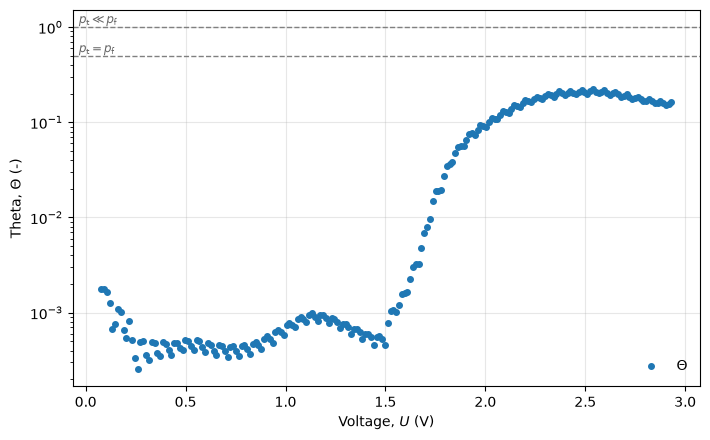

In [10]:
fig_t, ax_t = plot_carrier_fraction(carriers)
apply_limits(ax_t, x=("auto", "auto"), y=("auto", "auto"))
figures["carrier_fraction"] = fig_t
crossings = equal_density_voltage(carriers.U, carriers.p_f, carriers.p_t)
peak = np.nanargmax(carriers.theta)
print(f"Theta peaks at {carriers.theta[peak]:.3f} "
      f"(U = {carriers.U[peak]:.2f} V, mu_eff = {mobility.mu_eff[peak]:.3e})")
print(f"p_t = p_f at: {np.array2string(crossings, precision=3)} V"
      if crossings.size else "p_t = p_f nowhere in this scan: Theta stays "
      f"below 1/2, so the charge never fills the transport band at "
      f"mu_0 = {params['mu_0']:.1e} m^2 V^-1 s^-1")

## Density of states

The two transport bands are parabolic. The localized trap profile is

$$g_t(E) = \frac{N_t}{4 k_B T_t \cosh[(E-E_t)/(k_B T_t)]}.$$

It integrates to $(\pi/4)N_t$, so $N_t$ is a concentration scale.
The next step evaluates occupations of these states.


k_B T_t = 2.59 meV; trap peaks at 4.545e+18 m^-3 eV^-1
trap integral 3.6914e+16 m^-3 = 0.7854 N_t (pi/4 = 0.7854)


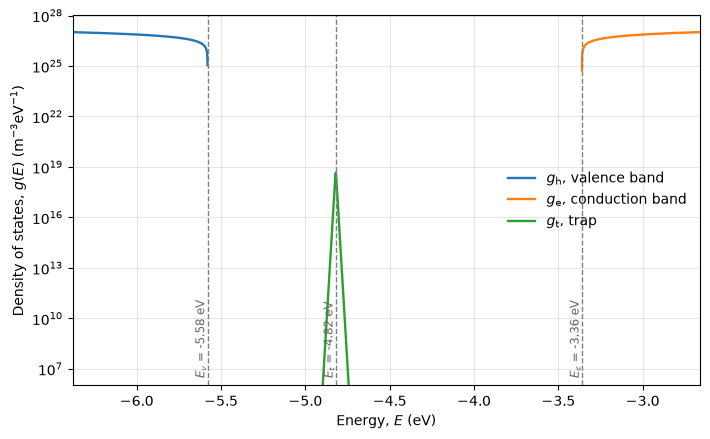

In [11]:
dos = dict(E_v=material["E_v"], E_c=material["E_c"],
           m_eff_h=material["m_eff_p"], m_eff_e=material["m_eff_e"],
           N_t=params["N_t"], E_t=params["E_t"], T_t=params["T_t"])

fig_d, ax_d = plot_dos(
    np.linspace(material["E_v"] - .8, material["E_c"] + .7, 36001), **dos)
apply_limits(ax_d, x=("auto", "auto"), y=("auto", "auto"))
figures["dos"] = fig_d

# The trap profile needs a grid fine enough to resolve it: k_B T_t is a
# few meV, so the full-range grid above samples it in about five points.
kt_t = K_B*params["T_t"]/E_CHARGE
close_up = np.linspace(params["E_t"] - 27*kt_t, params["E_t"] + 27*kt_t, 20001)
peak = params["N_t"]/(4*kt_t)

saturation = np.trapezoid(
    trap_dos(close_up, N_t=params["N_t"], E_t=params["E_t"], T_t=params["T_t"]),
    close_up)
print(f"k_B T_t = {kt_t*1e3:.2f} meV; trap peaks at {peak:.3e} m^-3 eV^-1")
print(f"trap integral {saturation:.4e} m^-3 = {saturation/params['N_t']:.4f} N_t "
      f"(pi/4 = {np.pi/4:.4f})")

## M2: Model occupations

Free populations are absolute, total populations are equilibrium-subtracted,
and the labelled trapped populations subtract the equilibrium free value.
Theta is `abs(free / total)` and can exceed one or diverge. Signed values
remain in `model`; nonpositive values leave gaps on logarithmic plots.


At EF0 = -4.84 eV: nf0 = 5.070557e-01, pf0 = 1.402200e+12 m^-3


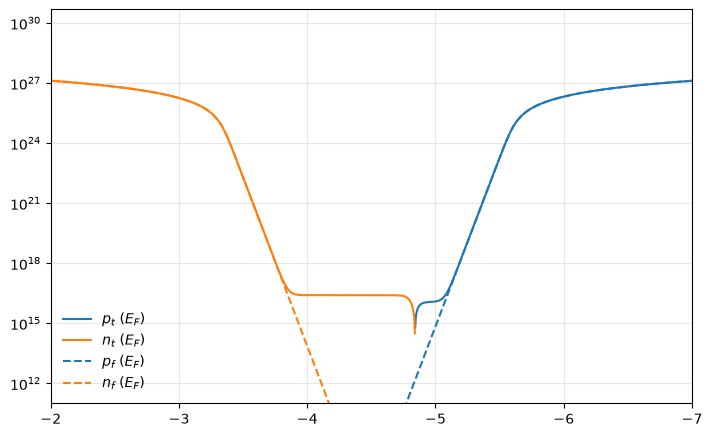

In [12]:

model_energy = -np.arange(3001) * 0.003
model_fermi = -9.0 + np.arange(3001) * 0.003
model = run_model_occupations(model_energy, model_fermi, material=material,
                              params=params, temperature=experiment["T"])
fig_m2, axes_m2 = plot_model_occupations(model)
apply_limits(axes_m2, x=(-2, -7), y=(10e10, "auto"))
figures["model_occupations"] = fig_m2
print(f"At EF0 = {model.E_F0:g} eV: nf0 = {model.n_f0:.6e}, "
      f"pf0 = {model.p_f0:.6e} m^-3")


## Fermi–Dirac occupation

Occupied and empty state probabilities versus relative energy $E-E_F$,
using the existing energy grid, equilibrium Fermi level and temperature.
Both probabilities equal one half at zero relative energy.


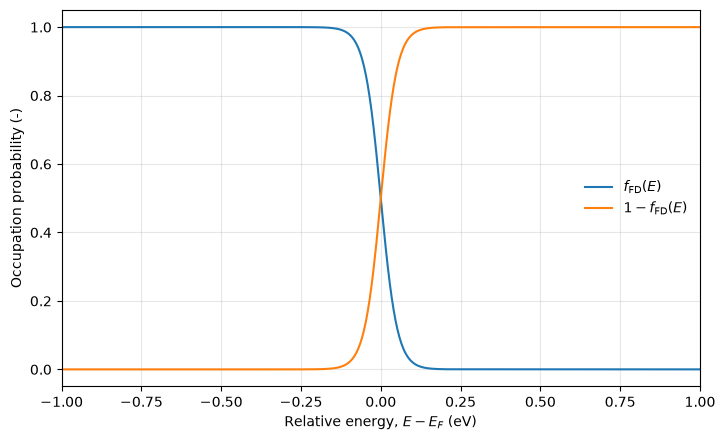

In [13]:
fig_fd, ax_fd = plot_fermi_dirac(
    model_energy - params["E_F0"],
    thermal_energy=K_B * experiment["T"] / E_CHARGE)
apply_limits(ax_fd, x=(-1, 1), y=("auto", "auto"))
figures["fermi_dirac"] = fig_fd


## Trapped charge, $n_t$ versus free charge, $n_f$

Measured and model carrier concentrations, including free-charge identity
series. The bottom axes are logarithmic; the independent top axis is
linear and reversed. Axis limits follow the calculated data.


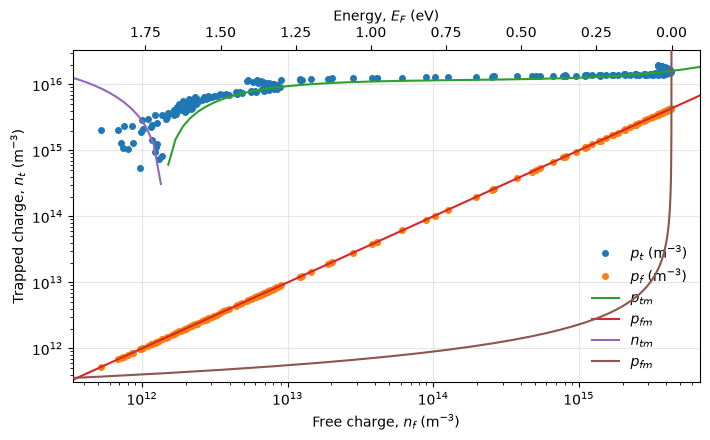

In [14]:
fig_tc, axes_tc = plot_trapped_charge(carriers, model)
apply_limits(axes_tc, x=("auto", "auto"), y=("auto", "auto"))
figures["trapped_charge"] = fig_tc


## Fermi energy

Measured free holes give $E_F=E_v+|k_BT\ln|p_f/N_v||$, with $k_BT$ in eV.
Both absolute values are retained. The current configured temperature is used
for the inversion and effective valence-band density of states. Invalid rows
remain gaps. Model energies retain their existing occupation-sweep coordinate.
The comparison against voltage is plotted after calculating the model voltage.


In [15]:
model_levels = run_model_fermi_level(model, material=material)
measured_levels = run_measured_fermi_level(
    carriers, material=material, temperature=experiment["T"])
print(f"Valid nondegenerate rows: {measured_levels.nondegenerate.sum()}")


Valid nondegenerate rows: 204


## M4: Model current density

On the existing energy sweep, use $q=n_t$ or $p_t$ and the corresponding
absolute free density $f$:

$$U=\frac{e L^2 q}{\varepsilon_0\varepsilon_r(1-\gamma)(2-\gamma)},
\qquad J=\frac{e\mu_0 f(2-\gamma)U}{L}.$$

Retain $\gamma=T_t/T$. The density mapping $q=s-f_0$ is an algebraic
continuation: it is not generally the total space charge required by
Poisson's equation. Electrons and holes are separate single-carrier curves.
Signed results remain in the arrays; nonpositive points leave gaps on the
logarithmic plot. The supplied gamma is a shape coefficient and need not
equal the slope measured along the resulting curve.

The log/log comparison plots $j_m(p_f)$ and $-j_m(n_f)$ against the
same hole voltage, paired by Fermi energy. The negated electron series
is a parametric comparison, not the electron current at that applied voltage.
The $m=1$ guide is $j=e\mu_0p_{f0}U/L$; the $m=2$ guide is
$j=9\varepsilon_0\varepsilon_r\mu_0U^2/(8L^3)$. Both use the existing
parameters, without fitting. Display limits follow measured data only.


M4 gamma: 0.10033445


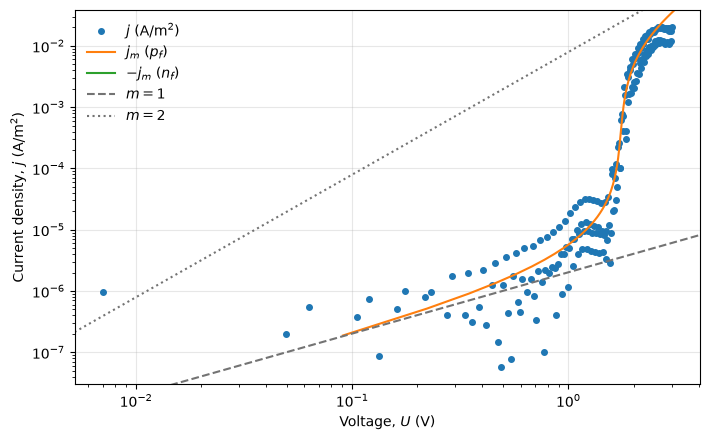

In [16]:
model_gamma = params["T_t"] / experiment["T"]
model_current = run_model_current(model, material=material,
                                  mu_0=params["mu_0"], gamma=model_gamma)
fig_m4, ax_m4 = plot_model_current(
    model_current, measured=result, material=material,
    mu_0=params["mu_0"], equilibrium_holes=model.p_f0)
apply_limits(ax_m4, x=("auto", "auto"), y=("auto", "auto"))
figures["model_current"] = fig_m4
print(f"M4 gamma: {model_current.gamma:.8g}")


## Voltage and current density versus Fermi energy

The four branches $U(n_t)$, $U(p_t)$, $j(n_f)$ and $j(p_f)$ use the existing M4 calculation. The horizontal coordinate is absolute $E_F$ in eV (linear); voltage in V uses the left logarithmic axis and current density in A/m² uses the right logarithmic axis. The voltage axis starts at 1 V and the current-density axis at 1 A/m²; upper limits and horizontal limits are automatic. Nonpositive values leave gaps without changing the calculated arrays.


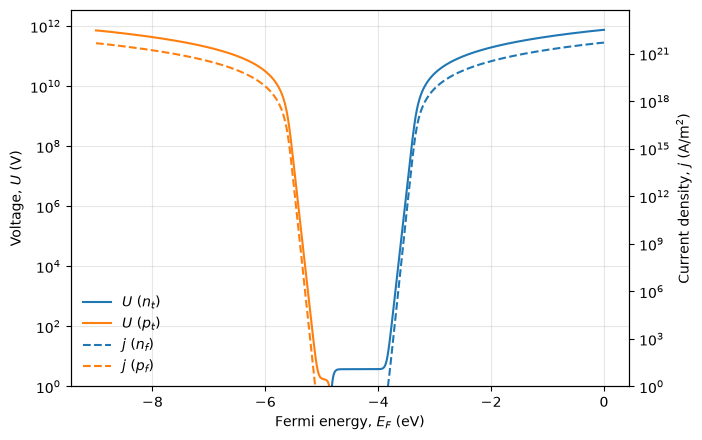

In [17]:
fig_te, axes_te = plot_model_transport_energy(model_current)
apply_limits(axes_te, x=("auto", "auto"), y=(1, "auto"))
figures["model_transport_energy"] = fig_te


## Current density versus voltage — linear/log

Measured current density and model hole current on a linear voltage axis
and logarithmic current axis, with voltage limits 0–4 V and current-density
limits $10^{-8}$–$10^0$ A/m². The hole branch uses
the voltage and current calculated above with the same parameters.


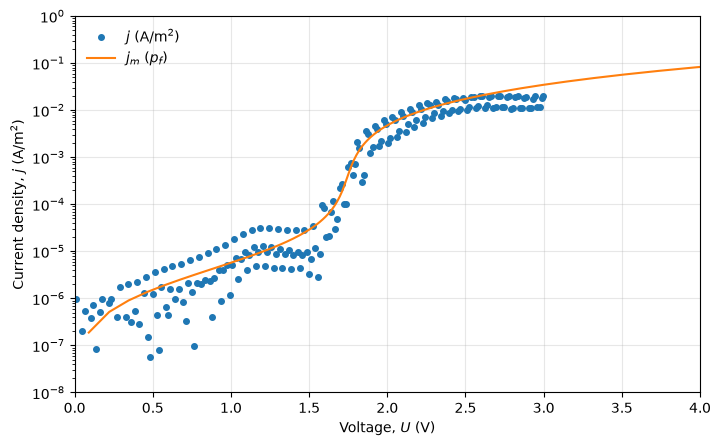

In [18]:
fig_h, ax_h = plot_hole_current_semilog(model_current, measured=result)
apply_limits(ax_h, x=(0, 4), y=(1e-8, 1e0))
figures["hole_current_semilog"] = fig_h


## Charge density versus voltage — linear/log

Measured free and trapped holes and model hole densities on the same
linear voltage and logarithmic density axes, with voltage limits 0–4 V
and density limits $10^{10}$–$10^{18}$ m⁻³.
Each model density is paired with its hole voltage at the same Fermi energy.
The legend uses hole notation $p$; the axis retains charge notation $n$.
Model $p_t=p_s-p_{f0}$ retains the existing equilibrium subtraction convention;
it is not a direct trapped-hole occupation integral.


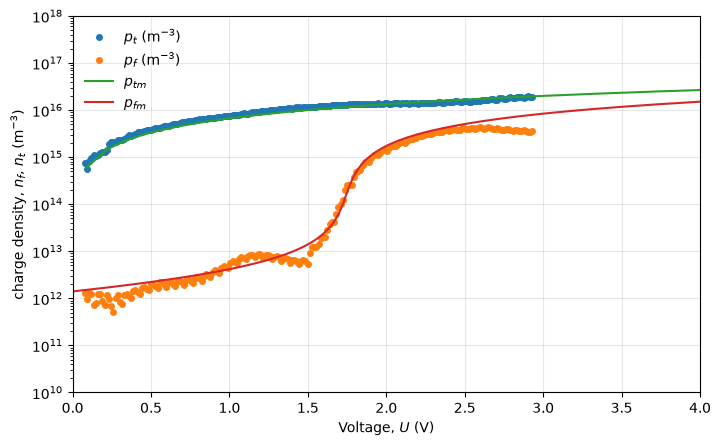

In [19]:
fig_p, ax_p = plot_carrier_densities(
    carriers, model=model, model_current=model_current)
apply_limits(ax_p, x=(0, 4), y=(1e10, 1e18))
figures["carrier_densities"] = fig_p


## Charge density versus voltage — log/log

Measured free and trapped holes and model hole densities on logarithmic
voltage and density axes. Both display limits follow the measured points.
Each model density is paired with its hole-branch voltage at the same
Fermi energy. Nonpositive or nonfinite coordinates cannot be displayed;
the calculated arrays retain all values.


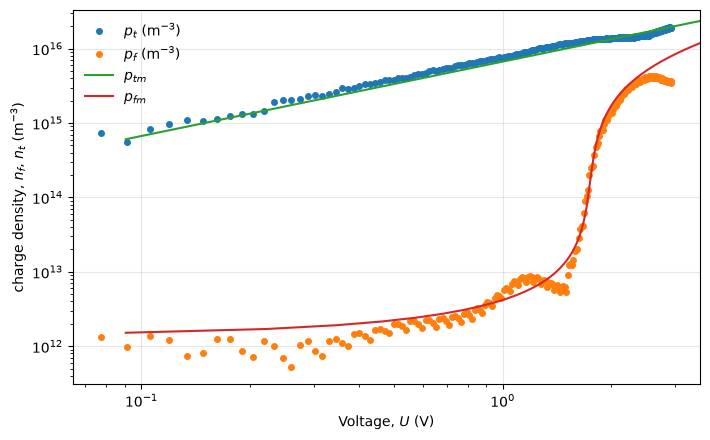

In [20]:
fig_plog, ax_plog = plot_carrier_densities(
    carriers, model=model, model_current=model_current, xscale="log")
apply_limits(ax_plog, x=("auto", "auto"), y=("auto", "auto"))
figures["carrier_densities_loglog"] = fig_plog


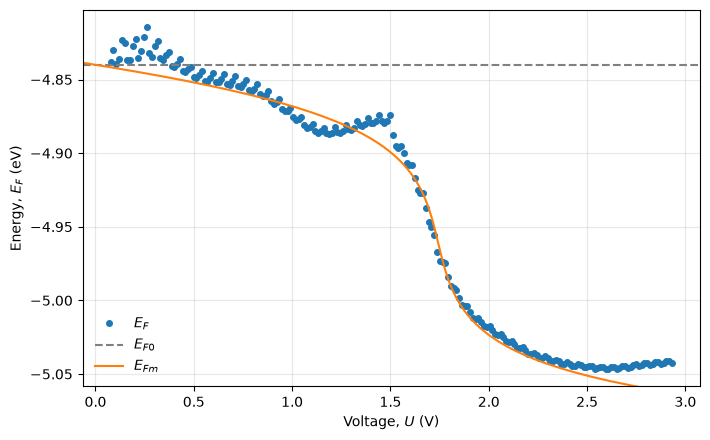

In [21]:
fig_ef, ax_ef = plot_fermi_energy(measured_levels, model_current, model_levels)
apply_limits(ax_ef, x=("auto", "auto"), y=("auto", "auto"))
figures["fermi_energy"] = fig_ef


## g(E), dn/dEF versus Energy, E, delta EF

The measured derivative is the absolute adjacent slope of $p_f+p_t$
against absolute $E_F$. The model derivative is the negative three-point
fitted slope of its excess total-hole population. Both are placed at the
first energy in their window; incomplete or invalid windows leave gaps.
DOS, derivatives and carrier populations retain their axis assignments.
Energy limits follow the measured range; both vertical axes are logarithmic.


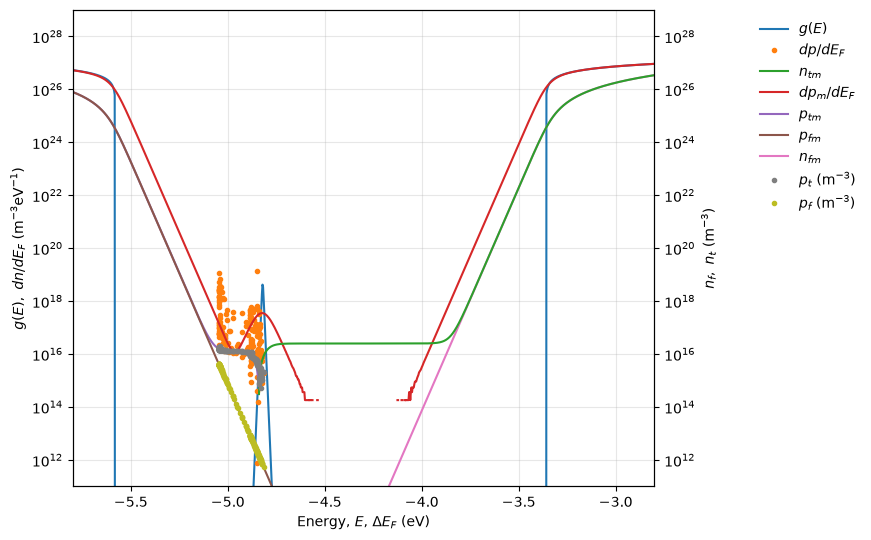

In [22]:
density_derivatives = run_density_derivatives(carriers, measured_levels, model)
dos_plot_energy = np.sort(np.unique(np.r_[model_energy, material['E_v'], material['E_c']]))
fig_de, axes_de = plot_density_energy(
    dos_plot_energy, total_dos(dos_plot_energy, **dos), carriers, measured_levels,
    model, density_derivatives)
apply_limits(axes_de, x=(-5.8, -2.8), y=(1e11, 1e29))
figures["density_energy"] = fig_de


## Theta versus voltage

Measured free-charge fraction and model $\Theta_m=|p_f/p_s|$ on the
hole-voltage branch. Linear voltage and logarithmic Theta; limits follow
the measured points. Model values above one remain in the arrays.


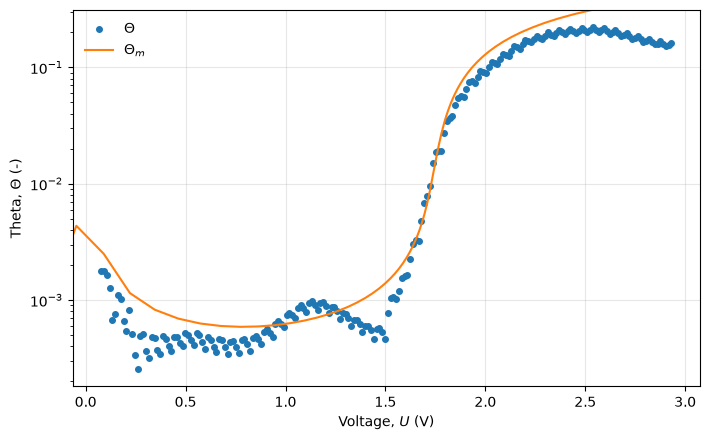

In [23]:
fig_t, ax_t = plot_carrier_fraction(carriers, model=model, model_current=model_current)
apply_limits(ax_t, x=("auto", "auto"), y=("auto", "auto"))
figures["carrier_fraction"] = fig_t


## Drift mobility versus voltage

Measured $\mu_d$, model hole mobility $\mu_{d,m}=\mu_0|p_f/p_s|$,
and the microscopic reference $\mu_0$ share linear voltage and logarithmic
mobility axes. Model mobility uses the same energy rows as the hole voltage.
Voltage limits and the lower mobility limit follow measured points.
The upper mobility limit is $10^{-2}$ m²/V/s to show the model curve
and $\mu_0$ reference; calculated values remain unchanged.


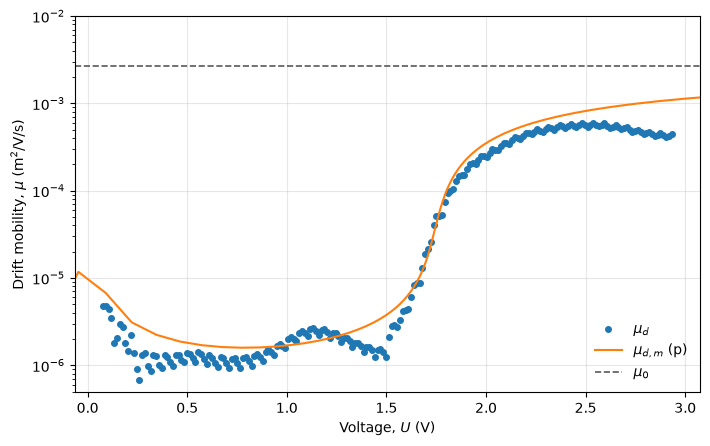

In [24]:
model_mobility = run_model_mobility(model, mu_0=params["mu_0"])
fig_m, ax_m = plot_effective_mobility(
    result, mobility, mu_0=params["mu_0"],
    model_mobility=model_mobility, model_current=model_current)
apply_limits(ax_m, x=("auto", "auto"), y=("auto", 1e-2))
figures["effective_mobility"] = fig_m


## Export

Save the figure as PNG/SVG and write the measured CSV to the output
directory.

In [25]:
output_dir = export_results(result, figures, project_root / "outputs")
print(f"Saved {len(figures)} figures and measured data to {output_dir}")

Saved 16 figures and measured data to /home/vk/WORK/asclc/outputs
